In [ ]:
# Intelligent Power Demand Forecasting

## Objective

The objective of this project is to develop a machine learning-based power demand forecasting system capable of predicting electricity consumption using historical load and weather data.

The dataset contains feeder-level electricity consumption measurements along with weather variables such as temperature, humidity, and wind speed. The forecasting system uses engineered temporal and weather features to estimate future power demand.

This notebook covers:

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
5. Model Training
6. Model Evaluation


In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Utility_consumption.csv")

print(df.shape)

df.head()

(52416, 7)


,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
0,01-01-2017 00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,01-01-2017 00:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,01-01-2017 00:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,01-01-2017 00:30,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,01-01-2017 00:40,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


In [ ]:
## Dataset Overview

The dataset contains historical electricity consumption data recorded at regular intervals along with weather information.

The objective of this section is to understand the structure of the dataset, identify data types, and verify data completeness before proceeding with analysis.


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Datetime                   52416 non-null  str    
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   WindSpeed                  52416 non-null  float64
 4   F1_132KV_PowerConsumption  52416 non-null  float64
 5   F2_132KV_PowerConsumption  52416 non-null  float64
 6   F3_132KV_PowerConsumption  52416 non-null  float64
dtypes: float64(6), str(1)
memory usage: 2.8 MB


In [19]:
df.isnull().sum()

Datetime                     0
Temperature                  0
Humidity                     0
WindSpeed                    0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
dtype: int64

In [ ]:
## Missing Value Analysis

The dataset was inspected for missing values across all columns.

Observation:

* No missing values were detected.
* All weather and power consumption features are complete.
* No imputation techniques were required.

This indicates that the dataset is suitable for direct analysis and model development.


In [ ]:
## Datetime Processing

The Datetime column was converted into a proper datetime format to enable time-series analysis and extraction of temporal features such as hour, day, month, and weekday.


In [20]:
df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    format="mixed"
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Datetime                   52416 non-null  datetime64[us]
 1   Temperature                52416 non-null  float64       
 2   Humidity                   52416 non-null  float64       
 3   WindSpeed                  52416 non-null  float64       
 4   F1_132KV_PowerConsumption  52416 non-null  float64       
 5   F2_132KV_PowerConsumption  52416 non-null  float64       
 6   F3_132KV_PowerConsumption  52416 non-null  float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 2.8 MB


In [ ]:
## Target Variable Creation

The dataset contains three feeder-level consumption measurements:

* F1_132KV_PowerConsumption
* F2_132KV_PowerConsumption
* F3_132KV_PowerConsumption

To forecast overall electricity demand, these values were aggregated into a single target variable called Total_Load.


In [21]:
# Create Total Load

df["Total_Load"] = (
    df["F1_132KV_PowerConsumption"]
    + df["F2_132KV_PowerConsumption"]
    + df["F3_132KV_PowerConsumption"]
)

# Time Features

df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["Month"] = df["Datetime"].dt.month
df["Weekday"] = df["Datetime"].dt.weekday

df["Weekend"] = (
    df["Weekday"] >= 5
).astype(int)

df.head()

,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_Load,Hour,Day,Month,Weekday,Weekend
0,2017-01-01 00:00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386,70425.53544,0,1,1,6,1
1,2017-01-01 00:10:00,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434,69320.84387,0,1,1,6,1
2,2017-01-01 00:20:00,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373,67803.22193,0,1,1,6,1
3,2017-01-01 00:30:00,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711,65489.23209,0,1,1,6,1
4,2017-01-01 00:40:00,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964,63650.44627,0,1,1,6,1


In [22]:
df["Total_Load"].describe()

count     52416.000000
mean      71222.885864
std       17143.138964
min       36785.039739
25%       56499.074640
50%       69788.790940
75%       83749.172310
max      134208.145950
Name: Total_Load, dtype: float64

In [ ]:
## Statistical Summary

The statistical summary provides information about the distribution of power demand.

Observations:

* Average demand is approximately 71,223 units.
* Peak demand exceeds 134,000 units.
* Demand values exhibit significant variation throughout the year, indicating seasonal and temporal effects.


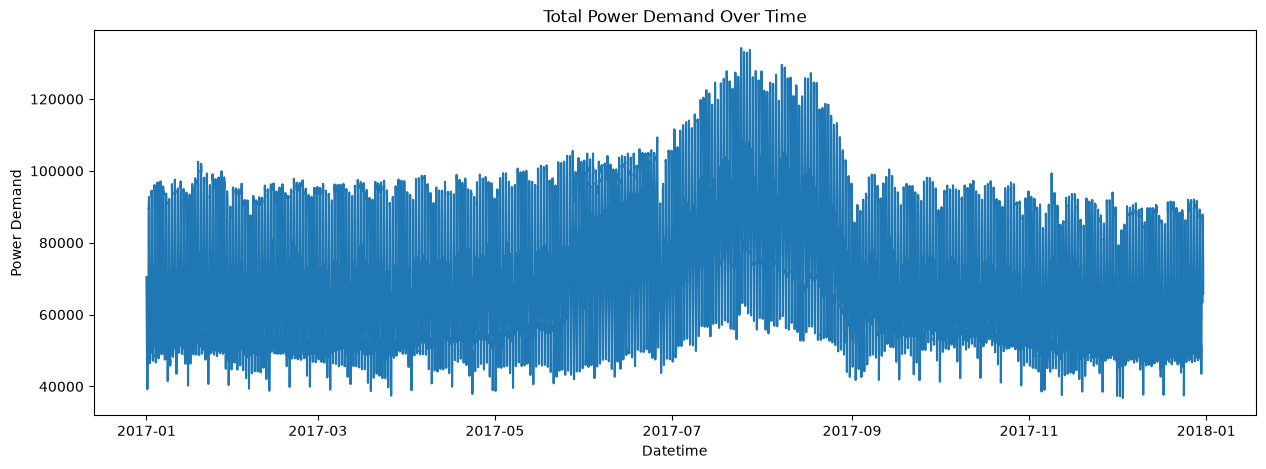

In [23]:
plt.figure(figsize=(15,5))

plt.plot(
    df["Datetime"],
    df["Total_Load"]
)

plt.title("Total Power Demand Over Time")
plt.xlabel("Datetime")
plt.ylabel("Power Demand")

plt.show()

In [ ]:
## Demand Trend Analysis

The power demand trend demonstrates recurring patterns over time.

Observations:

* Clear seasonal behavior is visible.
* Demand increases during certain periods of the year.
* Short-term fluctuations indicate daily demand cycles.

These observations suggest that temporal features will be important predictors for forecasting.


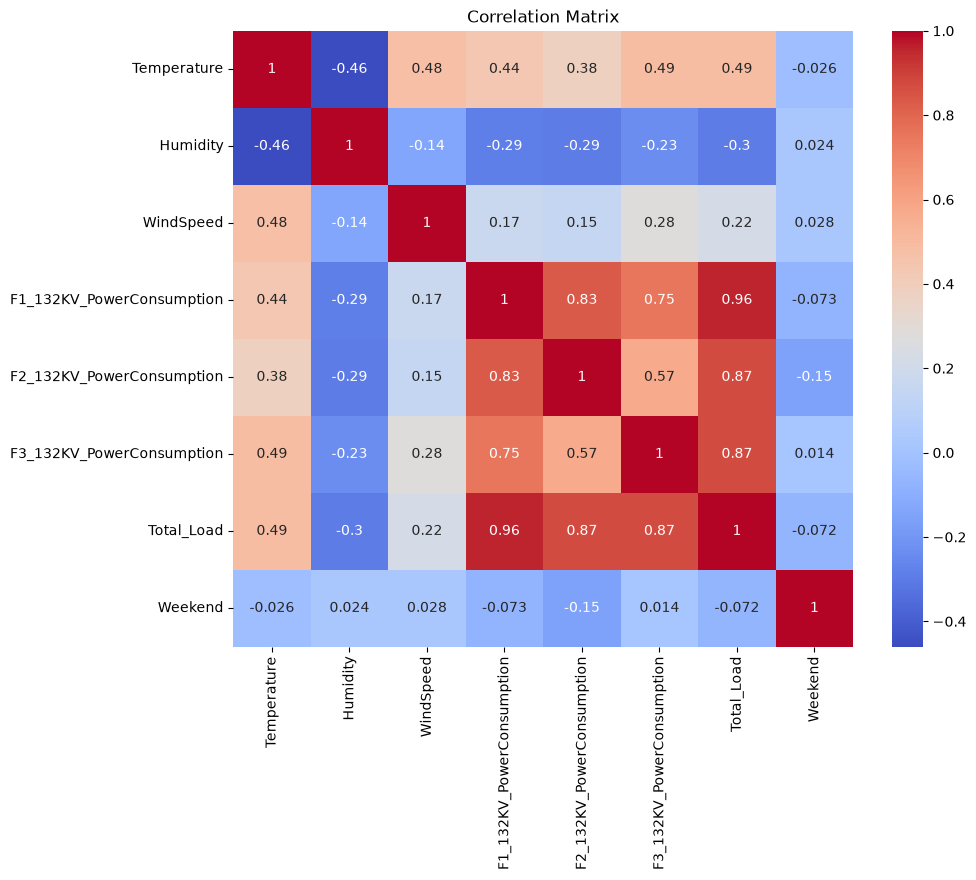

In [24]:
corr = df.select_dtypes(include=["float64","int64"]).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
## Correlation Analysis

The correlation matrix was used to examine relationships between weather variables and electricity demand.

Observations:

* Temperature exhibits moderate positive correlation with Total_Load.
* Humidity shows weak negative correlation with demand.
* Feeder-level consumption values are strongly correlated with Total_Load.
* Weather variables contribute useful predictive information for forecasting.


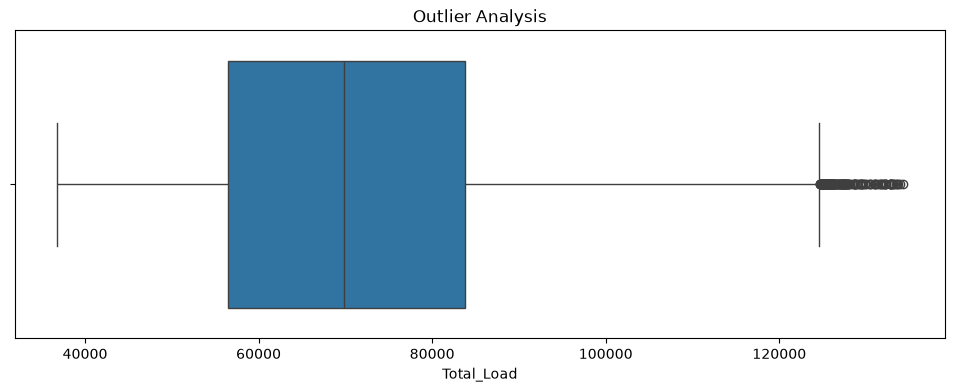

In [25]:
plt.figure(figsize=(12,4))

sns.boxplot(
    x=df["Total_Load"]
)

plt.title("Outlier Analysis")

plt.show()

In [ ]:
## Outlier Analysis

Outlier detection was performed using a boxplot of Total_Load.

Observations:

* A small number of high-demand observations were identified.
* These points represent genuine peak-demand events rather than data errors.
* Outliers were retained because they contain important information for forecasting peak electricity demand.


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

In [ ]:
## Feature Engineering

Time-based features were extracted from the Datetime column to capture temporal patterns in electricity demand.

Generated features:

* Hour
* Day
* Month
* Weekday
* Weekend

These features help the model learn daily, weekly, and seasonal demand behavior.


In [27]:
features = [
    "Temperature",
    "Humidity",
    "WindSpeed",
    "Hour",
    "Day",
    "Month",
    "Weekday",
    "Weekend"
]

X = df[features]
y = df["Total_Load"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print("MAE:", mae)

MAE: 1288.7863552609037


In [29]:
joblib.dump(model, "../backend/model.pkl")

['../backend/model.pkl']

In [ ]:
## Model Selection and Results

A Random Forest Regressor was selected due to its ability to capture nonlinear relationships between weather conditions and power demand without requiring extensive preprocessing.

Features Used:

* Temperature
* Humidity
* WindSpeed
* Hour
* Day
* Month
* Weekday
* Weekend

Target Variable:

* Total_Load

Evaluation Strategy:

* Train/Test Split: 80/20
* Metric: Mean Absolute Error (MAE)

Results:

* MAE = 1288.79

The model achieved low prediction error relative to the average load demand, indicating that weather and calendar-based features provide strong predictive capability for short-term electricity demand forecasting.
